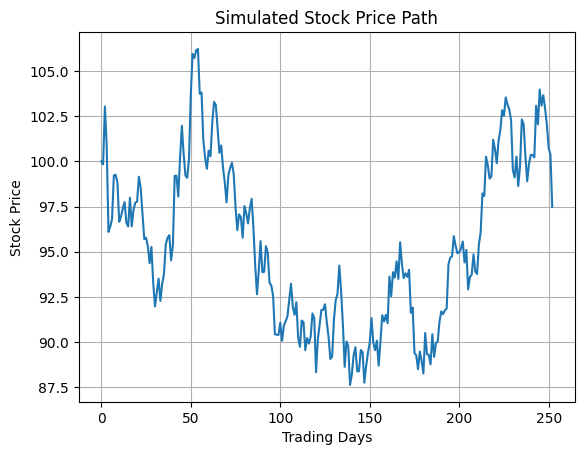

In [1]:
# -- Simulate a Singular Stock Path

# Import 
import sys
import os

sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from src.monte_carlo import (
    simulate_stock_path,
    simulate_multiple_paths,
    monte_carlo_call_price,
    monte_carlo_put_price
)

from src.black_scholes import (
    call_price,
    put_price
)

# Create a Path 
path = simulate_stock_path(
    S = 100,
    T = 1,
    r = 0.05,
    sigma = 0.2,
    steps = 252
)

# Plot The Data
plt.plot(path)

plt.title("Simulated Stock Price Path")
plt.xlabel("Trading Days")
plt.ylabel("Stock Price")

plt.grid(True)
plt.show()

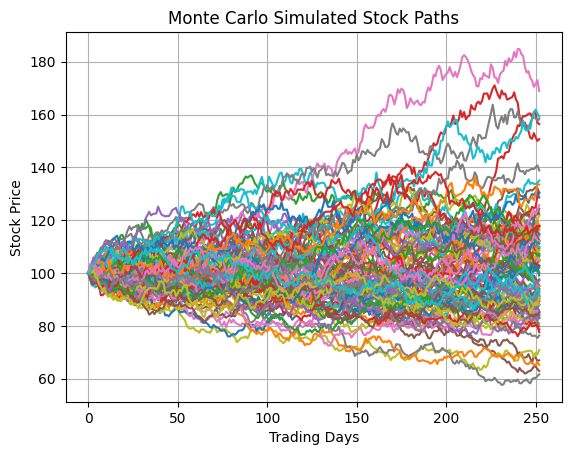

In [ ]:
# -- Simulate Multiple Stock Paths

# Import 
import sys
import os

sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from src.monte_carlo import (
    simulate_stock_path,
    simulate_multiple_paths,
    monte_carlo_call_price,
    monte_carlo_put_price
)

from src.black_scholes import (
    call_price,
    put_price
)

# Create the Paths 
paths = simulate_multiple_paths(
    S=100,
    T=1,
    r=0.05,
    sigma=0.2,
    steps=252,
    num_simulations=100
)

for path in paths:
    plt.plot(path)

plt.title("Monte Carlo Simulated Stock Paths")
plt.xlabel("Trading Days")
plt.ylabel("Stock Price")

plt.grid(True)
plt.show()

In [3]:
# -- Compare Monte Carlo Pricing to Black Scholes

# Import 
import sys
import os

sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from src.monte_carlo import (
    simulate_stock_path,
    simulate_multiple_paths,
    monte_carlo_call_price,
    monte_carlo_put_price
)

from src.black_scholes import (
    call_price,
    put_price
)

# Create the Call Price 
mc_call = monte_carlo_call_price(
    S=100,
    K=100,
    T=1,
    r=0.05,
    sigma=0.2,
    steps=252,
    num_simulations=10000
)

bs_call = call_price(100, 100, 1, 0.05, 0.2)

# Compare 
print("Monte Carlo: ", mc_call)
print("Black-Scholes: ", bs_call)


Monte Carlo:  10.6367428165578
Black-Scholes:  10.450583572185565


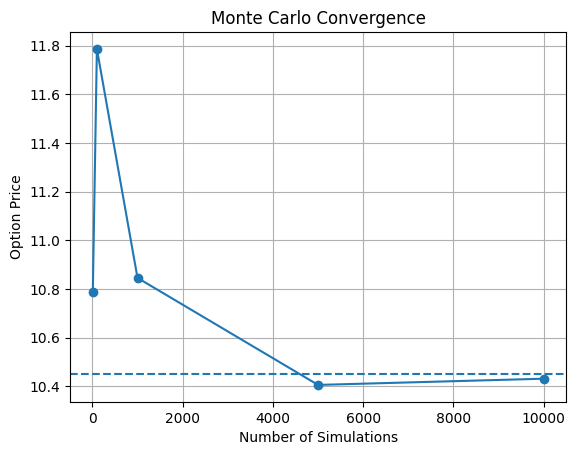

In [7]:
# -- Monte Carlo Estimates with Varying Simulation Counts

# Import 
import sys
import os

sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from src.monte_carlo import (
    simulate_stock_path,
    simulate_multiple_paths,
    monte_carlo_call_price,
    monte_carlo_put_price
)

from src.black_scholes import (
    call_price,
    put_price
)

# Create the Simulation Counts 
simulation_counts = [10, 100, 1000, 5000, 10000]
prices = []

# Compute Estimates 
for n in simulation_counts:
    price = monte_carlo_call_price(
        S=100,
        K=100,
        T=1,
        r=0.05,
        sigma=0.2,
        steps=252,
        num_simulations=n
    )

    prices.append(price)

# Plot the Data 
plt.plot(simulation_counts, prices, marker='o')

plt.axhline(
    y=call_price(100,100,1,0.05,0.2),
    linestyle='--'
)

plt.title("Monte Carlo Convergence")
plt.xlabel("Number of Simulations")
plt.ylabel("Option Price")

plt.grid(True)
plt.show()
